In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from arch import arch_model

torch.manual_seed(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data = pd.read_csv('IBM.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)
data['return'] = 100 * np.log(data['Close_IBM']).diff()
data = data.dropna().reset_index(drop=True)
returns = data['return'].to_numpy(dtype='float32')
dates = data['Date']
test_size = 30
validation_size = 60
train = returns[:-test_size-validation_size]
validation = returns[-test_size-validation_size:-test_size]
test = returns[-test_size:]
test_dates = dates.iloc[-test_size:]
realized_volatility = pd.Series(returns).rolling(5).std().iloc[-test_size:].to_numpy()

In [3]:
garch_candidates = []
for p, q, dist in [(1, 1, 'normal'), (1, 1, 't'), (1, 2, 't'), (2, 1, 't')]:
    fit = arch_model(train, mean='Constant', vol='GARCH', p=p, q=q, dist=dist, rescale=False).fit(disp='off')
    garch_candidates.append((fit.bic, p, q, dist, fit))
garch_candidates.sort(key=lambda x: x[0])
garch_bic, garch_p, garch_q, garch_dist, garch_fit = garch_candidates[0]
garch_origin = np.concatenate([train, validation])
garch_final_fit = arch_model(garch_origin, mean='Constant', vol='GARCH', p=garch_p, q=garch_q, dist=garch_dist, rescale=False).fit(disp='off')
garch_forecast = garch_final_fit.forecast(horizon=test_size, reindex=False)
garch_test_volatility = np.sqrt(garch_forecast.variance.iloc[-1].to_numpy())
print(f'GARCH({garch_p},{garch_q}), {garch_dist}, training BIC: {garch_bic:.3f}')

GARCH(1,1), t, training BIC: 47458.345


In [2]:
context = 20
dimension = 16
heads = 2
degrees_of_freedom = 5.0

def windows(values):
    x = np.array([values[i:i+context] for i in range(len(values)-context)], dtype='float32')
    y = np.array([values[i+context] for i in range(len(values)-context)], dtype='float32')
    return torch.tensor(x), torch.tensor(y)

x_train, y_train = windows(train)
x_validation, y_validation = windows(np.concatenate([train[-context:], validation]))
loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)

class PositionalEncoding(nn.Module):
    def __init__(self):
        super().__init__()
        position = torch.arange(context).unsqueeze(1)
        frequency = torch.exp(torch.arange(0, dimension, 2) * (-math.log(10000.0) / dimension))
        encoding = torch.zeros(context, dimension)
        encoding[:, 0::2] = torch.sin(position * frequency)
        encoding[:, 1::2] = torch.cos(position * frequency)
        self.register_buffer('encoding', encoding.unsqueeze(0))
    def forward(self, x):
        return x + self.encoding[:, :x.shape[1]]

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(1, dimension)
        self.position = PositionalEncoding()
        layer = nn.TransformerEncoderLayer(d_model=dimension, nhead=heads, dim_feedforward=4*dimension, dropout=0.1, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)
        self.output = nn.Linear(dimension, 2)
    def forward(self, x, target=None):
        x = self.position(self.input(x.unsqueeze(-1)))
        mask = torch.triu(torch.ones(context, context, device=x.device), diagonal=1).bool()
        parameters = self.output(self.encoder(x, mask=mask)[:, -1])
        mean = parameters[:, 0]
        scale = torch.nn.functional.softplus(parameters[:, 1]) + 1e-4
        distribution = torch.distributions.StudentT(degrees_of_freedom, mean, scale)
        loss = None if target is None else -distribution.log_prob(target).mean()
        return distribution, loss
    @torch.no_grad()
    def forecast(self, values, horizon):
        self.eval()
        history = list(values.astype('float32'))
        scales = []
        for _ in range(horizon):
            x = torch.tensor(history[-context:], device=device).unsqueeze(0)
            distribution, _ = self(x)
            scales.append((distribution.scale * torch.sqrt(torch.tensor(degrees_of_freedom / (degrees_of_freedom - 2), device=device))).item())
            history.append(distribution.sample().item())
        return np.array(scales)

transformer = TransformerModel().to(device)
optimizer = torch.optim.AdamW(transformer.parameters(), lr=2e-3, weight_decay=1e-4)

C:\Users\trist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


0 1.765629768371582 2.2443902492523193
10 1.7455941438674927 2.262540102005005
20 1.7446962594985962 2.260831117630005
30 1.7466635704040527 2.267914056777954


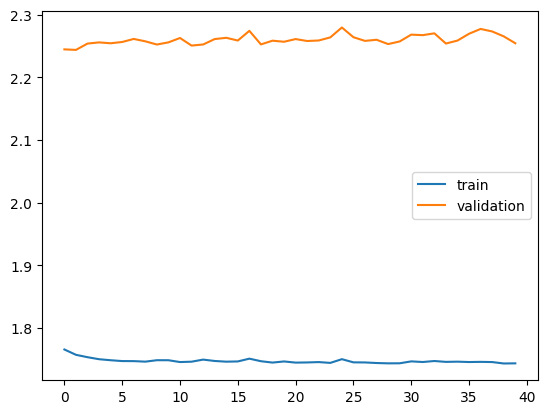

In [4]:
train_losses = []
validation_losses = []
for epoch in range(40):
    transformer.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, loss = transformer(x, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        optimizer.step()
    transformer.eval()
    with torch.no_grad():
        _, train_loss = transformer(x_train.to(device), y_train.to(device))
        _, validation_loss = transformer(x_validation.to(device), y_validation.to(device))
    train_losses.append(train_loss.item())
    validation_losses.append(validation_loss.item())
    if epoch % 10 == 0:
        print(epoch, train_loss.item(), validation_loss.item())

plt.plot(train_losses, label='train')
plt.plot(validation_losses, label='validation')
plt.legend()
plt.show()

GARCH MSE: 3.013230
Transformer MSE: 4.873848


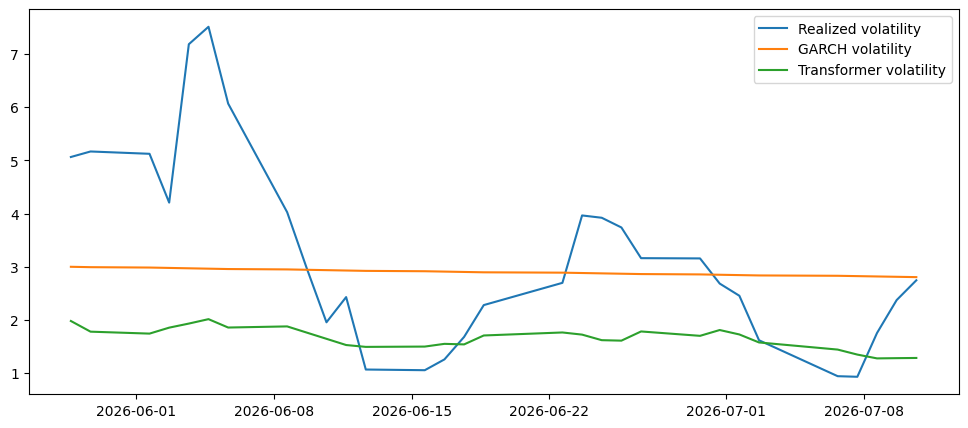

,Date,GARCH volatility,Transformer volatility,Realized volatility
0,2026-05-28 16:00:00,3.000026,1.981194,5.063924
1,2026-05-29 16:00:00,2.992887,1.780468,5.167736
2,2026-06-01 16:00:00,2.985780,1.743920,5.124139
3,2026-06-02 16:00:00,2.978706,1.856074,4.206568
4,2026-06-03 16:00:00,2.971664,1.932679,7.184130
5,2026-06-04 16:00:00,2.964654,2.015715,7.511954
6,2026-06-05 16:00:00,2.957676,1.858197,6.067803
7,2026-06-08 16:00:00,2.950729,1.879409,4.026470
8,2026-06-09 16:00:00,2.943815,1.762585,2.968932
9,2026-06-10 16:00:00,2.936932,1.646034,1.956505


In [5]:
transformer_test_volatility = transformer.forecast(garch_origin, test_size)
garch_mse = np.mean((garch_test_volatility - realized_volatility) ** 2)
transformer_mse = np.mean((transformer_test_volatility - realized_volatility) ** 2)
comparison = pd.DataFrame({
    'Date': test_dates.to_numpy(),
    'GARCH volatility': garch_test_volatility,
    'Transformer volatility': transformer_test_volatility,
    'Realized volatility': realized_volatility,
})
print(f'GARCH MSE: {garch_mse:.6f}')
print(f'Transformer MSE: {transformer_mse:.6f}')
plt.figure(figsize=(12, 5))
plt.plot(comparison['Date'], comparison['Realized volatility'], label='Realized volatility')
plt.plot(comparison['Date'], comparison['GARCH volatility'], label='GARCH volatility')
plt.plot(comparison['Date'], comparison['Transformer volatility'], label='Transformer volatility')
plt.legend()
plt.show()
comparison